## Simulate the model under constant gain learning

In [1]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [2]:
# Parameter calibration
a = 1.001 # mean of the dividend process
gamma = 2.0 # risk aversion
sigma = 0.01 # std dev of the dividend process
sigma_x = 0.01 # std dev of the observable variable
delta = 0.96 # discount factor
phi = np.exp(sigma**2 / 2) # correction term for lognormality
kappa = delta * a ** ( - gamma) * phi
w = - np.log(kappa) - np.exp(-10)  # small constant to ensure positivity
constant_gain = 0.01  # constant gain parameter for learning

## Univariate case

In [3]:
# # Initialization
# T = 100 # number of time periods
# x = np.random.normal(0, sigma_x, T) # observable variable
# r = np.zeros(T) # actual gross returns
# beta = np.zeros(T) # coefficient for the observable variable
# M = np.zeros(T)

# #Starting values
# beta[0] = np.random.normal(0, 0.001) #small perturbation around REE
# beta[1] = np.random.normal(0, 0.001)
# M[0] = sigma_x ** 2 # initial variance of the observable variable 
# r[1] = np.random.normal(0, 0.0001) 

# for t in range(2, T):
#     # update M
#     M[t-1] = M[t-2] + (x[t-2]**2 - M[t-2]) * constant_gain
#     # update beta using RLS
#     beta[t] = beta[t-1] + constant_gain * ( M[t-1]) ** -1 * (x[t-2] * r[t-1] - x[t-2]**2 * beta[t-1])
#     # compute expected returns
#     r[t] = np.log(1 - kappa * np.exp(w * np.tanh(beta[t-1] * x[t-1] / w))) - np.log(1 - kappa * np.exp(w * np.tanh(beta[t] * x[t] / w))) + np.random.normal(0, sigma)


In [4]:
# #visualize beta coefficient over time
# fig, ax = plt.subplots()
# ax.plot(beta, label='Beta estimate')
# ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
# ax.set_ylabel('Beta')
# ax.set_xlabel('Time')
# ax.legend()
# plt.show()

## Multivariate case (2 is enough)

In [5]:

def multivariate_CGL(T, K, sigma_x, sigma, kappa, w, constant_gain, seed=None):
    """Simulate constant-gain (geometrically-weighted) learning for K predictors.

    Returns
    -------
    beta : (T, K) array
    r    : (T,) array of log-returns
    x    : (T, K) array of predictors
    """
    rng = np.random.default_rng(seed)
    x = rng.normal(0.0, sigma_x, size=(T, K))
    # log dividend shock ~ N(-sigma^2/2, sigma^2) so var is sigma^2
    log_eps = rng.normal(-0.5*sigma**2, sigma, size=T)

    beta = np.zeros((T, K))
    M = np.zeros((T, K, K))
    r = np.zeros(T)

    # start near REE
    beta[0] = rng.normal(0.0, 1e-3, size=K)
    M[0] = np.eye(K) * (sigma_x**2)

    # lag placeholders for the 'previous' term in returns
    beta_lag = beta[0].copy()
    x_lag = np.zeros(K)

    def g(beta_vec, x_vec):
        return np.log(1.0 - kappa * np.exp(w * np.tanh((beta_vec @ x_vec) / w)))

    for t in range(T-1):
        # realized return at t+1 (uses beta_lag, x_lag and current beta[t], x[t])
        r[t+1] = log_eps[t+1] + g(beta_lag, x_lag) - g(beta[t], x[t])

        # update second-moment estimate
        M[t+1] = M[t] + constant_gain * (np.outer(x[t], x[t]) - M[t])
        # numerical guard
        if np.linalg.cond(M[t+1]) > 1e12:
            M[t+1] = M[t+1] + 1e-10*np.eye(K)

        # update beta (RLS / WLS form with constant gain)
        innov = r[t+1] - (x[t] @ beta[t])
        beta[t+1] = beta[t] + constant_gain * (np.linalg.solve(M[t+1], x[t]) * innov)

        # shift lags
        beta_lag = beta[t].copy()
        x_lag = x[t].copy()

    return beta, r, x


In [ ]:

def multivariate_CGL_offline(T, K, sigma_x, sigma, kappa, w rolling_window_size=30, seed=None):
    """Offline rolling-window OLS benchmark.

    For each t >= rolling_window_size, estimate beta_t by OLS on the last window
    of observations (x_{t-rolling_window_size:t}, r_{t-rolling_window_size+1:t+1}).
    Then generate r_{t+1} using the same bounded pricing functional form.
    """
    assert rolling_window_size < T, "rolling_window_size must be less than T"
    rng = np.random.default_rng(seed)

    x = rng.normal(0.0, sigma_x, size=(T, K))
    log_eps = rng.normal(-0.5*sigma**2, sigma, size=T)

    beta_offline = np.zeros((T, K))
    r_offline = np.zeros(T)

    def g(beta_vec, x_vec):
        return np.log(1.0 - kappa * np.exp(w * np.tanh((beta_vec @ x_vec) / w)))

    # initialize with small noise
    beta_offline[:rolling_window_size] = rng.normal(0.0, 1e-3, size=(rolling_window_size, K))
    r_offline[:rolling_window_size] = rng.normal(0.0, 1e-4, size=rolling_window_size)

    beta_lag = beta_offline[0].copy()
    x_lag = np.zeros(K)

    for t in range(rolling_window_size, T-1):
        # OLS on the window (predict r_{i+1} from x_i)
        Xw = x[t-rolling_window_size:t]
        yw = r_offline[t-rolling_window_size+1:t+1]
        # pseudo-inverse for stability
        beta_offline[t] = np.linalg.pinv(Xw.T @ Xw) @ (Xw.T @ yw)

        # generate next return using (beta_lag, x_lag) and current beta_offline[t], x[t]
        r_offline[t+1] = log_eps[t+1] + g(beta_lag, x_lag) - g(beta_offline[t], x[t])

        beta_lag = beta_offline[t].copy()
        x_lag = x[t].copy()

    return beta_offline, r_offline, x


In [13]:
beta, r, x = multivariate_CGL(T=1000, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, constant_gain=constant_gain, seed=42)

In [8]:
beta_offline, r_offline = multivariate_CGL_offline(T=1000, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w, rolling_window_size=150)

ValueError: too many values to unpack (expected 2)

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

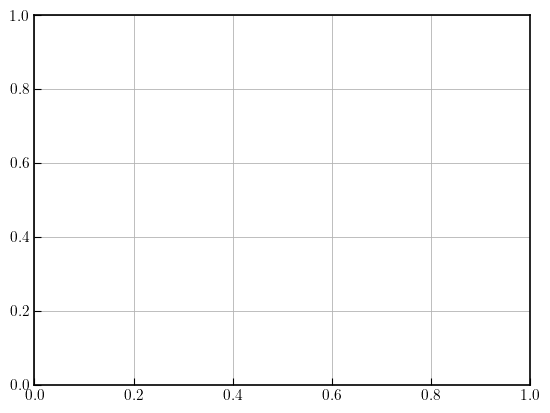

In [14]:
#visualzie the two betas over time
fig, ax = plt.subplots()
ax.plot(beta[:, 0, 0], label='Beta 1 estimate')
ax.plot(beta[:, 1, 0], label='Beta 2 estimate', color = 'gray')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
#add offline estimates
ax.plot(beta_offline[:, 0, 0], label='Beta 1 offline estimate', linestyle='dashed', color = 'blue')
ax.plot(beta_offline[:, 1, 0], label='Beta 2 offline estimate', linestyle='dashed', color = 'red')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

NameError: name 'r_offline' is not defined

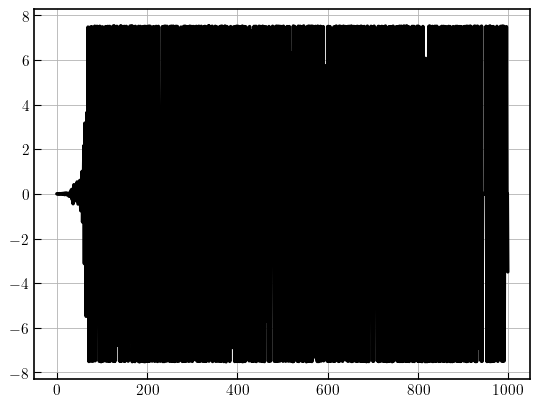

In [15]:
#visualize online vs offline returns
fig, ax = plt.subplots()
ax.plot(r, label='Online returns')
ax.plot(r_offline, label='Offline returns', linestyle='dashed', alpha = 0.3)
ax.set_ylabel('Returns')
ax.set_xlabel('Time')
ax.legend()
plt.show()

In [ ]:
## Check with multiple stochastic seeds to ensure robustness
num_simulations = 10
all_betas = []
for sim in range(num_simulations):
    np.random.seed(sim)
    beta, r = multivariate_CGL(T=100, K=2, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w)
    all_betas.append(beta)

/var/folders/hb/bc0srnt52zx6lbw4t2k_t_k80000gn/T/ipykernel_58542/2604373990.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r[t] = np.log(1 - kappa * np.exp(w * np.tanh((beta[t-1, :, 0] @ x[t-1, :].reshape(-1, 1)) / w))) - np.log(1 - kappa * np.exp(w * np.tanh((beta[t, :, 0] @ x[t, :].reshape(-1, 1)) / w))) + np.random.normal(0, sigma)


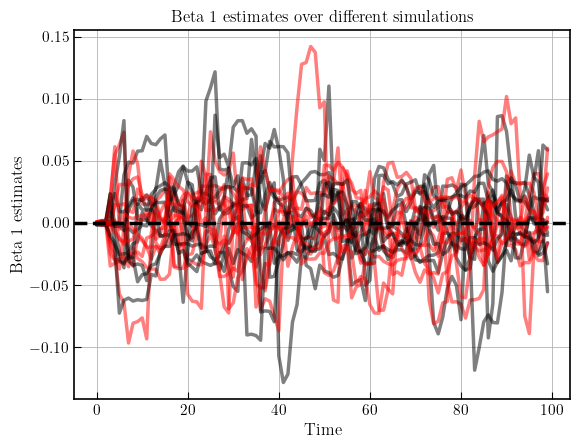

In [ ]:
#visualization of coefficients over seeds
fig, ax = plt.subplots()
for sim in range(num_simulations):
    ax.plot(all_betas[sim][:, 0, 0], alpha=0.5, label = 'beta_1')
    ax.plot(all_betas[sim][:, 1, 0], alpha=0.5, color = 'red', label = 'beta_2')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta 1 estimates')
ax.set_xlabel('Time')
ax.set_title('Beta 1 estimates over different simulations')
plt.show()


## Monte Carlo check: simulated vs theoretical distribution of $\beta_t$

For the univariate case ($K=1$), the theory predicts (for small constant gain) that the stationary distribution of the learning coefficient is approximately

$$
\beta_t \approx \mathcal N\left(0,\; \gamma\,\frac{\sigma^2(1-\kappa)}{2\sigma_x^2}\right),
$$

where in this notebook `sigma` is the standard deviation of $\log(\varepsilon^d_t)$ and `constant_gain` is the gain parameter.


In [ ]:

import matplotlib.pyplot as plt
from math import sqrt, pi

def theoretical_beta_var(constant_gain, sigma, sigma_x, kappa):
    return constant_gain * sigma**2 * (1.0 - kappa) / (2.0 * sigma_x**2)

# Monte Carlo settings
N_paths = 300
T_mc = 60000
burn = 10000
thin = 10

beta_draws = []
for n in range(N_paths):
    beta_path, r_path, x_path = multivariate_CGL(
        T=T_mc, K=1, sigma_x=sigma_x, sigma=sigma, kappa=kappa, w=w,
        constant_gain=constant_gain, seed=1000+n
    )
    # collect post-burn-in, thinned draws
    beta_draws.append(beta_path[burn::thin, 0])

beta_draws = np.concatenate(beta_draws)

var_th = theoretical_beta_var(constant_gain, sigma, sigma_x, kappa)
sd_th = np.sqrt(var_th)

print("Draws:", beta_draws.size)
print("Sim mean:", beta_draws.mean())
print("Sim var :", beta_draws.var(ddof=1))
print("Theory var:", var_th)

# Plot histogram vs theoretical normal density
xs = np.linspace(beta_draws.min(), beta_draws.max(), 400)
pdf = (1.0/(sd_th*sqrt(2*pi))) * np.exp(-0.5*(xs/sd_th)**2)

plt.figure(figsize=(8,4.5))
plt.hist(beta_draws, bins=80, density=True, alpha=0.6, label="Simulated")
plt.plot(xs, pdf, linewidth=2, label="Theoretical N(0,var)")
plt.title("Stationary distribution of $\beta_t$ (constant gain, K=1)")
plt.xlabel(r"$\beta$")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# QQ plot and a simple KS test (if SciPy is available)
try:
    from scipy import stats
    fig = plt.figure(figsize=(6,6))
    stats.probplot(beta_draws, dist=stats.norm(loc=0, scale=sd_th), plot=plt)
    plt.title("QQ plot vs theoretical normal")
    plt.tight_layout()
    plt.show()

    ks = stats.kstest(beta_draws, 'norm', args=(0.0, sd_th))
    print("KS statistic:", ks.statistic)
    print("KS p-value  :", ks.pvalue)
except Exception as e:
    print("SciPy not available (or QQ/KS failed):", e)
